 3D Image Segmentation Pipeline – Step 03: Calculating the Distance Transform
---

# Description
This notebook applies a **voxel-wise 3D watershed** on a **distance transform** within a binary mask.
Labels from a **marker (seed) array** are propagated through the volume level by level (descending distance), roughly following **Meyer’s flooding algorithm**.

**Inputs:**
- `distance` — 3D float/uint array of distances (larger = deeper inside object).
- `binary` — 3D boolean/uint8 mask selecting the region to segment.
- `marker` — 3D int array of initial seed labels (0 = background/unlabeled).

**Output:**
- `labels_levels` — 4D int array `(num_levels, X, Y, Z)` holding the label map after each flooding level; the **last** level is the final segmentation.


## Part of Pipeline
- **Previous Step**: Find seedpoints
- **Next Step**: Extraction of analytical data

## Requirements
- Python 3.11
- Libraries:
  - matplotlib
  - numpy

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt

from src.visualisation import (
    plot_3d_volume_voxels,
plot_2d_slice_with_values,
    plot_panels,
)

# Integrate figures into notebook
%matplotlib notebook
%matplotlib inline
plt.close()


### Inputs & assumptions

We need three arrays with the same shape `(X, Y, Z)`:

- `distance` — distance transform (larger = deeper inside objects).
- `binary` — mask selecting the region to segment (`True`/non-zero).
- `marker` — integer seed labels (0 = unlabeled).
  **Tip:** Place markers at **local maxima of `distance`** inside `binary`.


In [2]:
# Load inputs
marker = np.load('../src/data/seedpoints.npy') # Markers/seedpoints
distance = np.load(file='../src/data/distance_transform.npy')    # Distance transform
binary = np.load(file='../src/data/binary_image.npy') # Binary image


### Step 1 — Level sorting and initialization

We sort all unique distance values **descending** and will process voxels at each level.
We keep two arrays:
- `labels`: the current label map (accumulated).
- `labels_levels`: a stack of label maps, one per level (for inspection).


In [3]:
distance_levels = np.unique(distance)[::-1]  # largest → smallest
labels = np.zeros_like(marker, dtype=int)
labels_levels = np.zeros((len(distance_levels), *distance.shape), dtype=int)

print("Number of distance levels:", len(distance_levels))


Number of distance levels: 11


### Step 2 — 26-connected neighborhood

We use all immediate neighbors (faces, edges, corners) via offsets $∈ (−1, 0, 1)^3 \ {(0,0,0)}$.

In [4]:
offsets = np.array(np.meshgrid([-1, 0, 1], [-1, 0, 1], [-1, 0, 1])).T.reshape(-1, 3)

neighbors = offsets[np.any(offsets != 0, axis=1)]
shape = np.array(distance.shape)

print("Neighbors per voxel:", neighbors.shape[0])  # should be 26


Neighbors per voxel: 26


### Step 3 — Process one level (didactic unroll)

For a single level `level = distance_levels[i]`:
1. Take voxels at that level within `binary`.
2. For each voxel:
   - Look at neighbor labels from the **previous (higher) levels**.
   - If none → seed with `marker[x,y,z]`.
   - If one → copy that label.
   - If multiple:
     - If equal → copy common label.
     - Else → **weighted voting** (faces=3, edges=2, corners=1).
3. Update `labels`; store a snapshot in `labels_levels[i]`.


In [5]:
# Index of the current watershed propagation level (0 = first expansion step)
i = 0

# Extract the actual distance value corresponding to this level
level = distance_levels[i]

# Create a boolean mask selecting only:
# 1) Voxels exactly at this distance level
# 2) Voxels that belong to the foreground (binary mask)
dl_mask = np.logical_and(distance == level, binary)

# Extract (x, y, z) coordinates of all voxels in this distance shell
dl_coords = np.argwhere(dl_mask)

# Create a temporary copy of the current labels.
# This prevents in-place updates from influencing neighboring decisions
# within the same distance level.
labels_step = labels.copy()

# Iterate through every voxel belonging to the current distance shell
for x, y, z in dl_coords:

    # Compute the absolute coordinates of all neighboring voxels
    # by adding the predefined neighbor offsets to the current voxel
    neigh = neighbors + np.array([x, y, z])

    # Filter neighbors that fall outside the image boundaries
    valid = np.all((neigh >= 0) & (neigh < shape), axis=1)
    neigh = neigh[valid]

    # Split valid neighbor coordinates for array indexing
    nx, ny, nz = neigh.T

    # Extract the current labels of all neighboring voxels
    neigh_vals = labels[nx, ny, nz]

    # ------------------------------------------------------------
    # LABEL ASSIGNMENT RULES
    # ------------------------------------------------------------

    # Case 1: All neighbors are still unlabeled (label == 0)
    # → Assign the voxel its original marker label
    if np.all(neigh_vals == 0):
        labels_step[x, y, z] = marker[x, y, z]

    else:
        # Select only neighbors that already have non-zero labels
        neigh_true = neigh_vals[neigh_vals != 0]

        # Case 2: Exactly one unique neighboring label exists
        # → Propagate that label directly
        if neigh_true.size == 1:
            labels_step[x, y, z] = neigh_true[0]

        # Case 3: Multiple neighbors exist but all share the same label
        # → Still propagate that label
        elif np.all(neigh_true == neigh_true[0]):
            labels_step[x, y, z] = neigh_true[0]

        # Case 4: Conflicting labels from different regions
        # → Resolve using a weighted directional voting scheme
        else:
            votes = {}

            # Loop through each neighbor and its corresponding label
            for (dx, dy, dz), lbl in zip(neigh - np.array([x, y, z]), neigh_vals):

                # Ignore unlabeled neighbors
                if lbl == 0:
                    continue

                # Count number of non-zero direction components
                # This distinguishes between:
                # - Face neighbors (1 non-zero axis)
                # - Edge neighbors (2 non-zero axes)
                # - Corner neighbors (3 non-zero axes)
                nzc = np.count_nonzero([dx, dy, dz])

                # Assign larger weights to more direct neighbors
                # Face neighbor → weight 3
                # Edge neighbor → weight 2
                # Corner neighbor → weight 1
                w = 3 if nzc == 1 else (2 if nzc == 2 else 1)

                # Accumulate weighted votes per label
                votes[lbl] = votes.get(lbl, 0) + w

            # Assign the label that received the maximum total vote
            labels_step[x, y, z] = max(votes, key=votes.get)

# Commit the completed propagation step for this distance level
labels = labels_step

# Store the result for this specific watershed level
labels_levels[i] = labels_step

# Diagnostic output showing how many voxels are now labeled
print("First level processed; labeled voxels:", (labels != 0).sum())

First level processed; labeled voxels: 1


### Step 4 — Full flooding (all levels)

We repeat the single‑level logic across all levels to build the final segmentati

In [6]:
labels = np.zeros_like(marker, dtype=int)
for dl_i, level in enumerate(distance_levels):
    labels_step = labels.copy()
    dl_mask = np.logical_and(distance == level, binary)
    dl_coords = np.argwhere(dl_mask)

    for x, y, z in dl_coords:
        neigh = neighbors + np.array([x, y, z])
        valid = np.all((neigh >= 0) & (neigh < shape), axis=1)
        neigh = neigh[valid]
        nx, ny, nz = neigh.T
        neigh_vals = labels[nx, ny, nz]

        if np.all(neigh_vals == 0):
            labels_step[x, y, z] = marker[x, y, z]
        else:
            neigh_true = neigh_vals[neigh_vals != 0]
            if neigh_true.size == 1:
                labels_step[x, y, z] = neigh_true[0]
            elif np.all(neigh_true == neigh_true[0]):
                labels_step[x, y, z] = neigh_true[0]
            else:
                votes = {}
                for (dx, dy, dz), lbl in zip(neigh - np.array([x, y, z]), neigh_vals):
                    if lbl == 0: continue
                    nzc = np.count_nonzero([dx, dy, dz])
                    w = 3 if nzc == 1 else (2 if nzc == 2 else 1)
                    votes[lbl] = votes.get(lbl, 0) + w
                labels_step[x, y, z] = max(votes, key=votes.get)

    labels = labels_step
    labels_levels[dl_i] = labels_step

final_labels = labels_levels[-1]

# Write labeled image
np.save(file='../src/data/labeled_image.npy', arr=final_labels)

print("Final labeled voxels:", (final_labels != 0).sum())


Final labeled voxels: 371


### Step 5 — Visualize and check
1. We visualise a 2d slice of the volume to demonstrate the application of the watershed algorithm onto the distance transform of the image,
2. We visualise the 3d volume with their assigned label as intensity. This will give us a clear picture, whether the watershed segmentation has been implemented succefully.

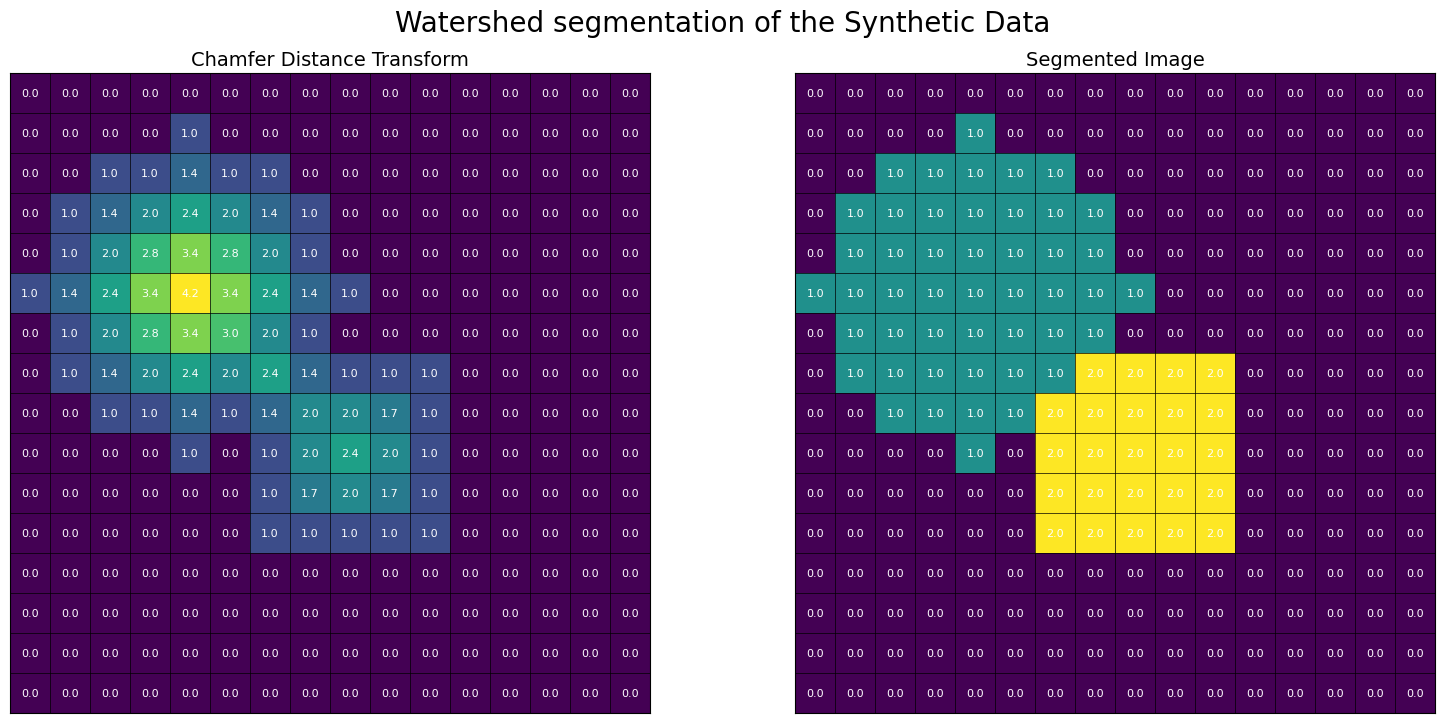

In [7]:
# Visualize a single 2D slice of the distance transform
plot_slice_index = 7 # Slice index to be visualised
plot_panels(
    n=2,
    data_list=[distance,final_labels],
    plot_func=plot_2d_slice_with_values,
    plot_kwargs_list=[{"slice_index": plot_slice_index},{"slice_index": plot_slice_index}],
    title="Watershed segmentation of the Synthetic Data",
    subtitles=["Chamfer Distance Transform","Segmented Image"]
)

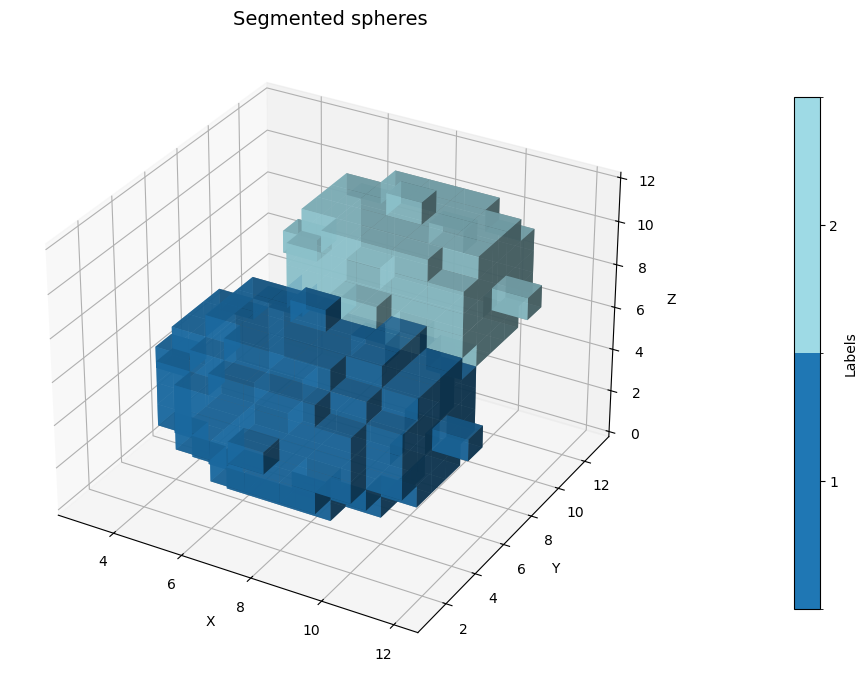

In [8]:
# Plot 3d voxel render of watershed segmentation
plot_panels(
    n=1,
    data_list=[final_labels],
    plot_func=plot_3d_volume_voxels,
    plot_kwargs_list=[
        {"threshold_lo": 1, "threshold_hi": 3},
        {"threshold_lo": 1, "threshold_hi": 3},
    ],
    title=None,  # no overall title in original call
    subtitles=["Segmented spheres",],
    projection="3d",
)

**Exercise 1:** Tie-Breaking Policy
   - Modify the weighted voting scheme for conflicting neighbors:
     - Current: faces = 3, edges = 2, corners = 1.
     - Try: faces = 5, edges = 3, corners = 1 or equal weights.
   - **Observe:** How do boundaries shift when conflicts occur?

**Exercise 2:** Connectivity Variants
   - Change neighborhood connectivity:
     - 6-connected (faces only)
     - 18-connected (faces + edges)
     - 26-connected (faces + edges + corners)
   - **Question:** How does connectivity affect segmentation boundaries?